# Supp Fig 3 — architecture ablation (Student-t)

Reproduces **SuppFig3** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 3 — architecture ablation (robustness)
**🟢 light (reads caches)** · source: `ablation_primary_figs.py (whole script)`

In [ ]:
#!/usr/bin/env python
"""Supplementary figures for the SPATNIC primary model ablation.

Reads comparison_results/ablation_primary/scores_long.parquet and renders a
3-panel figure illustrating WHY SPATNIC wins: robustness under domain shift.

  A  Sensitivity vs Specificity, internal -> external (arrows = degradation)
  B  |degradation| of sensitivity & specificity (internal -> external)
  C  External score distribution by true label, Student-t vs Gaussian VAE
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT = COMP / "ablation_primary"
df = pd.read_parquet(OUT / "scores_long.parquet")

METHODS = ["Student-t VAE (SPATNIC)", "Gaussian VAE", "MLP (supervised)",
           "Random Forest", "Logistic Regression", "XGBoost"]
SHORT = {"Student-t VAE (SPATNIC)": "SPATNIC\n(Student-t VAE)", "Gaussian VAE": "Gaussian VAE",
         "MLP (supervised)": "MLP", "Random Forest": "Random Forest",
         "Logistic Regression": "LogReg", "XGBoost": "XGBoost"}
COLORS = {"Student-t VAE (SPATNIC)": "#D55E00", "Gaussian VAE": "#0072B2",
          "MLP (supervised)": "#009E73", "Random Forest": "#CC79A7",
          "Logistic Regression": "#E69F00", "XGBoost": "#7F7F7F"}

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "savefig.dpi": 300, "savefig.bbox": "tight", "figure.dpi": 130,
})


def sens_spec(g):
    y = g.y_true.values
    p = (g.score.values >= 0.5).astype(int)
    tp = ((y == 1) & (p == 1)).sum(); fn = ((y == 1) & (p == 0)).sum()
    tn = ((y == 0) & (p == 0)).sum(); fp = ((y == 0) & (p == 1)).sum()
    return tp / (tp + fn), tn / (tn + fp)


stat = {}
for m in METHODS:
    stat[m] = {}
    for ts in ["internal", "external"]:
        stat[m][ts] = sens_spec(df[(df.test_set == ts) & (df.method == m)])

fig = plt.figure(figsize=(15, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.25, 1.0], wspace=0.32)

# ---- Panel A: Sens-Spec scatter with internal->external arrows ----
axA = fig.add_subplot(gs[0, 0])
for m in METHODS:
    si, pi = stat[m]["internal"]
    se, pe = stat[m]["external"]
    c = COLORS[m]
    axA.annotate("", xy=(pe, se), xytext=(pi, si),
                 arrowprops=dict(arrowstyle="-|>", color=c, lw=1.6, alpha=0.7))
    axA.scatter([pi], [si], s=55, facecolors="white", edgecolors=c, linewidths=1.8, zorder=3)
    axA.scatter([pe], [se], s=75, color=c, zorder=4,
                edgecolors="black" if "SPATNIC" in m else "none",
                linewidths=1.4 if "SPATNIC" in m else 0)
    axA.annotate(SHORT[m].replace("\n", " "), (pe, se),
                 textcoords="offset points", xytext=(6, -4 if "Random" not in m else 6),
                 fontsize=7.5, color=c, fontweight="bold" if "SPATNIC" in m else "normal")
axA.set_xlabel("Specificity (Normal correct)")
axA.set_ylabel("Sensitivity (Tumor correct)")
axA.set_title("A  Robustness under domain shift\n(open=internal → filled=external)", loc="left")
axA.set_xlim(0.55, 1.0); axA.set_ylim(0.72, 1.01)
axA.grid(alpha=0.25)
axA.axvspan(0.9, 1.0, color="green", alpha=0.04)
axA.axhspan(0.9, 1.01, color="green", alpha=0.04)

# ---- Panel B: degradation magnitude ----
axB = fig.add_subplot(gs[0, 1])
x = np.arange(len(METHODS)); w = 0.38
d_sens = [stat[m]["internal"][0] - stat[m]["external"][0] for m in METHODS]
d_spec = [stat[m]["internal"][1] - stat[m]["external"][1] for m in METHODS]
axB.bar(x - w / 2, d_sens, w, label="Δ Sensitivity", color="#4C72B0")
axB.bar(x + w / 2, d_spec, w, label="Δ Specificity", color="#DD8452")
axB.axhline(0, color="k", lw=0.8)
axB.set_xticks(x)
axB.set_xticklabels([SHORT[m].replace("\n", " ") for m in METHODS], rotation=30, ha="right", fontsize=8)
axB.set_ylabel("Performance drop  internal → external")
axB.set_title("B  Smaller bar = more robust", loc="left")
axB.legend(frameon=False, fontsize=9)
axB.grid(axis="y", alpha=0.25)
# highlight SPATNIC tick
axB.get_xticklabels()[0].set_color(COLORS[METHODS[0]])
axB.get_xticklabels()[0].set_fontweight("bold")

# ---- Panel C: external score distributions, Student-t vs Gaussian ----
axC = fig.add_subplot(gs[0, 2])
bins = np.linspace(0, 1, 41)
pairs = [("Student-t VAE (SPATNIC)", "#D55E00"), ("Gaussian VAE", "#0072B2")]
for m, c in pairs:
    g = df[(df.test_set == "external") & (df.method == m)]
    for lab, ls in [(1, "-"), (0, "--")]:
        s = g[g.y_true == lab].score.values
        h, _ = np.histogram(s, bins=bins, density=True)
        axC.plot(0.5 * (bins[1:] + bins[:-1]), h, ls, color=c, lw=1.8,
                 alpha=0.9 if lab == 1 else 0.65)
axC.axvline(0.5, color="grey", lw=0.8, ls=":")
axC.set_xlabel("Predicted Tumor score (external)")
axC.set_ylabel("density")
axC.set_title("C  Score separation on external\n(solid=true Tumor, dashed=true Normal)", loc="left")
handles = [Line2D([0], [0], color="#D55E00", lw=2, label="SPATNIC (Student-t)"),
           Line2D([0], [0], color="#0072B2", lw=2, label="Gaussian VAE")]
axC.legend(handles=handles, frameon=False, fontsize=8.5, loc="upper center")
axC.grid(alpha=0.25)

fig.suptitle("SPATNIC primary ablation — why Student-t VAE generalises: "
             "it keeps both sensitivity and specificity under domain shift",
             fontsize=12.5, y=1.04, x=0.02, ha="left")

for ext in ("png", "pdf"):
    fig.savefig(OUT / f"ablation_robustness.{ext}")
print("saved:", OUT / "ablation_robustness.png", "and .pdf")

# also dump the numeric table behind panels A/B
tab = pd.DataFrame({
    "method": METHODS,
    "sens_internal": [stat[m]["internal"][0] for m in METHODS],
    "spec_internal": [stat[m]["internal"][1] for m in METHODS],
    "sens_external": [stat[m]["external"][0] for m in METHODS],
    "spec_external": [stat[m]["external"][1] for m in METHODS],
    "d_sens": d_sens, "d_spec": d_spec,
})
tab.to_csv(OUT / "sens_spec_shift.csv", index=False)
print(tab.round(3).to_string(index=False))

## Published result (reference)
Embedded reference output; the code above regenerates it.

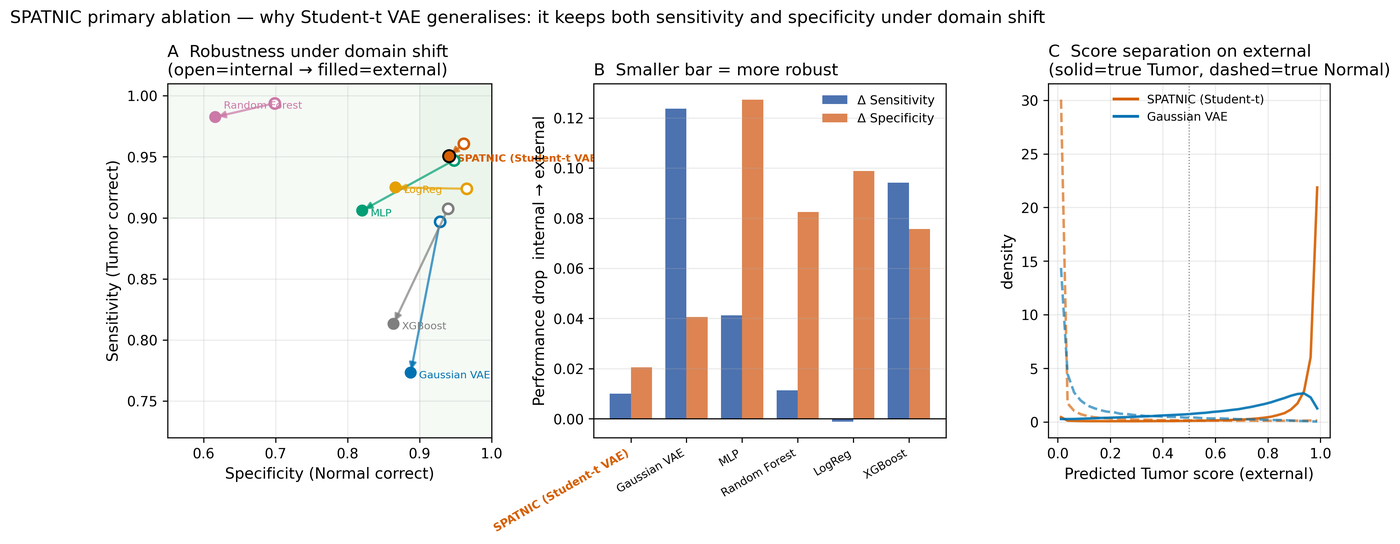

In [ ]:
# Architecture ablation robustness
Image(str(COMP / "ablation_primary/ablation_robustness.png"))